In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_churn.csv")

pd.set_option("display.max_columns",21)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df[df["TotalCharges"].isna()][["tenure","TotalCharges"]]

,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [10]:
dfd = df.copy()

In [11]:
dfd = dfd.drop(columns=["customerID"])

In [12]:
dfd.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
dfd["Churn"] = dfd["Churn"].map({"Yes":1,"No":0})

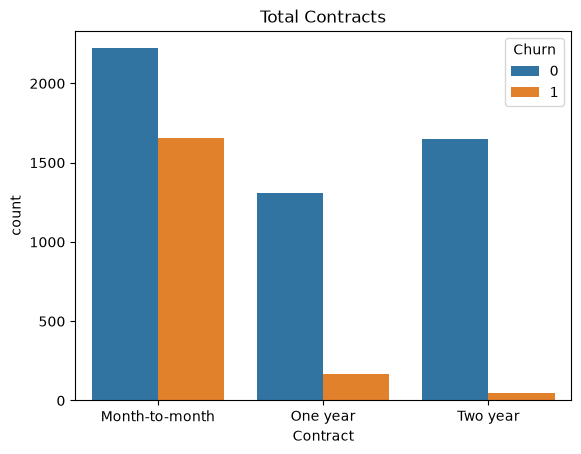

In [14]:
sns.countplot(data=dfd, x="Contract", hue="Churn")
plt.title("Total Contracts")
plt.show()

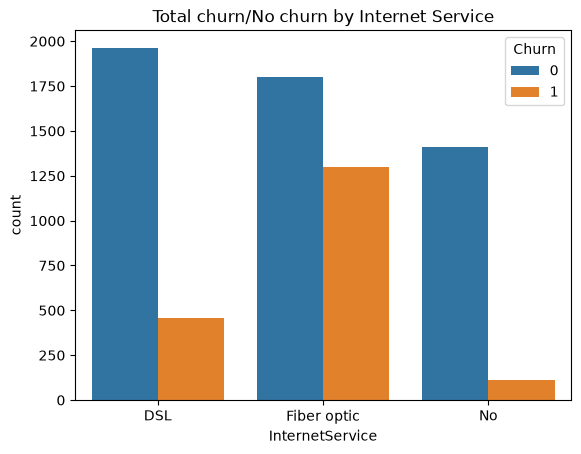

In [15]:
sns.countplot(x="InternetService", hue="Churn", data=dfd)
plt.title("Total churn/No churn by Internet Service")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_15796\3640034465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dfd, x="Churn", y="tenure", palette=["#2ecc71","#e74c3c"])


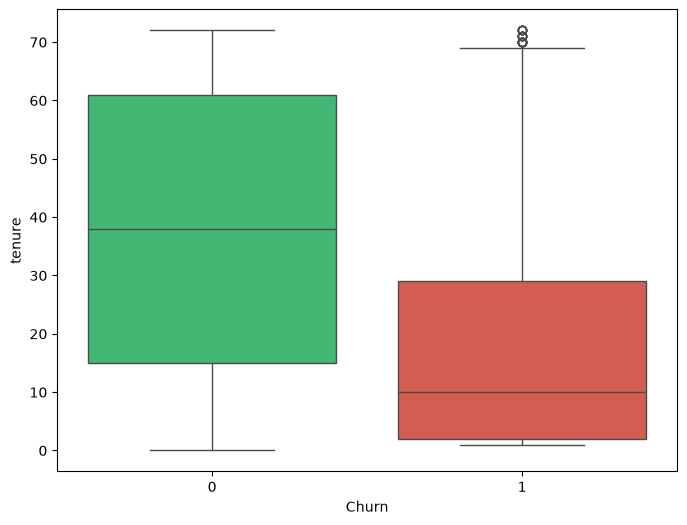

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(data=dfd, x="Churn", y="tenure", palette=["#2ecc71","#e74c3c"])
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_15796\3550567017.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Churn", y="MonthlyCharges", data=dfd, palette=("#2ecc71","#e74c3c"))


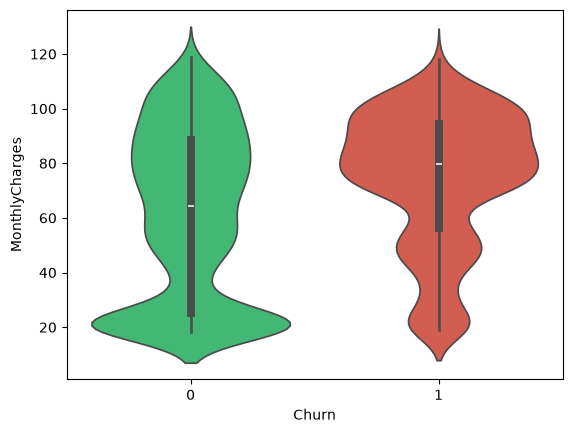

In [17]:
sns.violinplot(x="Churn", y="MonthlyCharges", data=dfd, palette=("#2ecc71","#e74c3c"))
plt.show()

In [18]:
num_col = dfd[["tenure","MonthlyCharges","TotalCharges","Churn"]].corr()

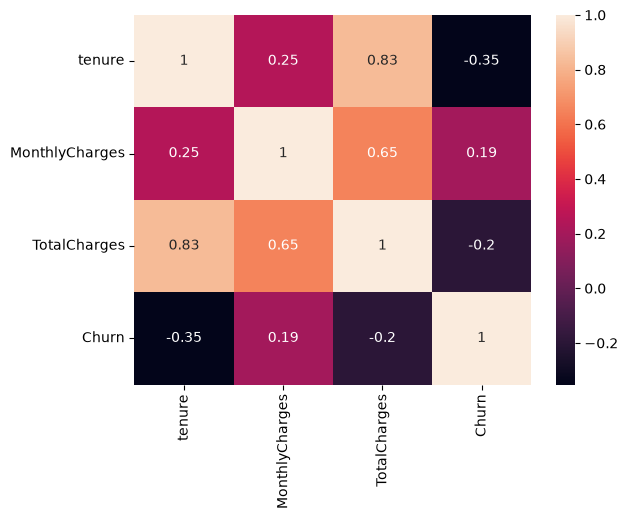

In [19]:
sns.heatmap(num_col, annot=True)
plt.show()

In [20]:
df.to_csv("cleaned_churn.csv", index=False)

In [21]:
# Prepare data for modeling


dfd_encoded = pd.get_dummies(dfd.drop("Churn", axis=1), drop_first=True)
X = dfd_encoded
y = dfd["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.02, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# Model, Compare 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


log_model = LogisticRegression(class_weight='balanced', max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("\nAccuracy:",accuracy_score(y_test, y_pred_log))
print(classification_report(y_test,y_pred_log ))
print("\nConfusion Matrix\n:", confusion_matrix(y_test,y_pred_log))

# Random forrest classifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("\nAccuracy:",accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix\n:", confusion_matrix(y_test,y_pred_rf))


Accuracy: 0.7801418439716312
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       104
           1       0.56      0.78      0.65        37

    accuracy                           0.78       141
   macro avg       0.73      0.78      0.75       141
weighted avg       0.82      0.78      0.79       141


Confusion Matrix
: [[81 23]
 [ 8 29]]

Accuracy: 0.7872340425531915
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       104
           1       0.59      0.65      0.62        37

    accuracy                           0.79       141
   macro avg       0.73      0.74      0.73       141
weighted avg       0.80      0.79      0.79       141


Confusion Matrix
: [[87 17]
 [13 24]]


In [30]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

for t in [0.2,0.25,0.3,0.35,0.4,0.45]:
    pred = (y_prob_log >= t).astype(int)
    report = classification_report(y_test, pred, output_dict=True)
    print(f"Threshold {t}: Recall(1) = {report['1']['recall']:.2f}, "
          f"Precision(1) = {report['1']['precision']:.2f}, "
          f"F1(1) = {report['1']['f1-score']:.2f}")

Threshold 0.2: Recall(1) = 0.95, Precision(1) = 0.42, F1(1) = 0.58
Threshold 0.25: Recall(1) = 0.89, Precision(1) = 0.45, F1(1) = 0.59
Threshold 0.3: Recall(1) = 0.89, Precision(1) = 0.46, F1(1) = 0.61
Threshold 0.35: Recall(1) = 0.89, Precision(1) = 0.49, F1(1) = 0.63
Threshold 0.4: Recall(1) = 0.84, Precision(1) = 0.48, F1(1) = 0.61
Threshold 0.45: Recall(1) = 0.81, Precision(1) = 0.52, F1(1) = 0.63


In [36]:
final_threshold = 0.35
y_pred_final = (y_prob_log >= final_threshold).astype(int)

print(classification_report(y_test,y_pred_final))
print("\nConfusion Matrix\n:",confusion_matrix(y_test,y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.66      0.78       104
           1       0.49      0.89      0.63        37

    accuracy                           0.72       141
   macro avg       0.72      0.78      0.70       141
weighted avg       0.82      0.72      0.74       141


Confusion Matrix
: [[69 35]
 [ 4 33]]
